# 01 — Setup LightGCN sur Yelp & premières mesures de biais

Ce notebook pose les bases de la Phase 1 (mesure) du plan expérimental :
1. Chargement des données Yelp (interactions + graphe social)
2. Calcul des premières métriques de biais au niveau des données (Niveau 1)
3. Premier aperçu de la corrélation entre biais

**Note :** en l'absence du dataset Yelp complet en local, les cellules ci-dessous
tournent sur des données synthétiques générées avec une distribution en loi de
puissance (proxy réaliste d'une distribution de popularité longue traîne),
le temps de finaliser le téléchargement et le formatage RecBole.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_loader import compute_item_popularity, train_test_split
from bias_metrics import gini_coefficient, exposure_bias, bias_correlation_matrix, embedding_norm_bias
from ips_correction import joint_correction, compute_propensity_scores

## 1. Données synthétiques (placeholder en attendant Yelp)

500 utilisateurs, 300 items, distribution d'interactions en loi de Zipf
pour simuler un biais de popularité réaliste.

In [2]:
rng = np.random.default_rng(42)
n_interactions = 20000

interactions = pd.DataFrame({
    "user_id": rng.integers(0, 500, n_interactions),
    "item_id": rng.zipf(a=1.8, size=n_interactions) % 300,
    "position": rng.integers(1, 20, n_interactions),
})

interactions.head()

,user_id,item_id,position
0,44,1,5
1,386,1,12
2,327,1,17
3,219,1,13
4,216,5,1


## 2. Split train/test

In [3]:
train_df, test_df = train_test_split(interactions, test_ratio=0.2)
print(f"Train: {len(train_df)} interactions | Test: {len(test_df)} interactions")

Train: 16208 interactions | Test: 3792 interactions


## 3. Niveau 1 — Biais dans les données

Coefficient de Gini sur la distribution de popularité des items : proche de 1
= concentration forte sur une minorité d'items (popularity bias marqué).

Coefficient de Gini (popularité des items) : 0.948


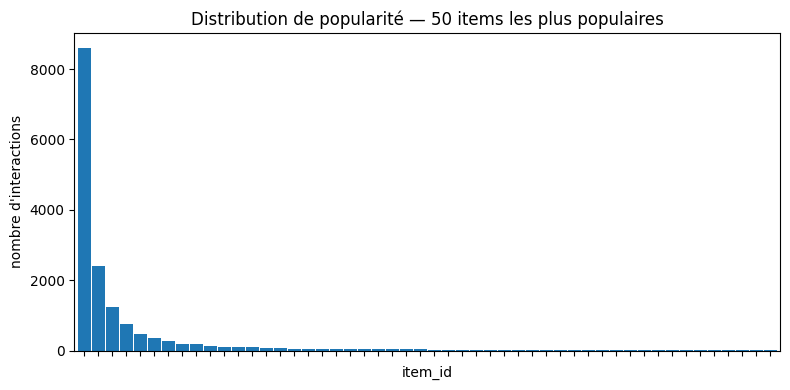

In [4]:
popularity = compute_item_popularity(train_df)
gini = gini_coefficient(popularity)
print(f"Coefficient de Gini (popularité des items) : {gini:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
popularity.head(50).plot(kind="bar", ax=ax, width=0.9)
ax.set_title("Distribution de popularité — 50 items les plus populaires")
ax.set_xlabel("item_id")
ax.set_ylabel("nombre d'interactions")
ax.set_xticklabels([])
plt.tight_layout()
plt.savefig("../results/popularity_distribution.png", dpi=120)
plt.show()

## 4. Exposure bias et propensity scores (préparation Phase 2)

In [5]:
exposure = exposure_bias(train_df)
propensity = compute_propensity_scores(train_df)

print("Exposition (top 5 items) :")
print(exposure.head())
print(f"\nPropensity scores — min={propensity.min():.3f} max={propensity.max():.3f} mean={propensity.mean():.3f}")

Exposition (top 5 items) :
item_id
1    0.530664
2    0.148445
3    0.076691
4    0.046212
5    0.028258
Name: count, dtype: float64

Propensity scores — min=0.100 max=0.631 mean=0.220


## 5. Corrélation entre indicateurs de biais

Aperçu préliminaire (sur données synthétiques) de la corrélation entre
popularité et exposition — à étendre avec les biais de conformité et de
position une fois le modèle LightGCN entraîné (Niveau 2 et 3).

In [6]:
corr_matrix = bias_correlation_matrix({
    "popularity": popularity,
    "exposure": exposure.reindex(popularity.index),
})
corr_matrix

,popularity,exposure
popularity,1.0,1.0
exposure,1.0,1.0


## 6. Poids IPS — correction jointe (préparation Phase 2)

Les poids calculés ici seront injectés dans la loss BPR de LightGCN
(`weighted_bpr_loss` dans `src/ips_correction.py`) une fois l'entraînement
branché sur RecBole.

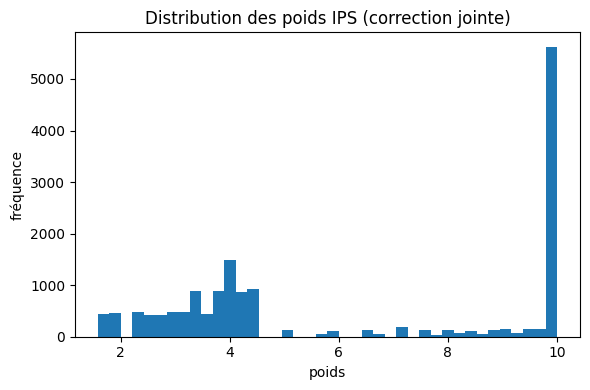

In [7]:
weights = joint_correction(train_df)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(weights, bins=40)
ax.set_title("Distribution des poids IPS (correction jointe)")
ax.set_xlabel("poids")
ax.set_ylabel("fréquence")
plt.tight_layout()
plt.savefig("../results/ips_weights_distribution.png", dpi=120)
plt.show()

## Prochaines étapes

- [ ] Remplacer les données synthétiques par le vrai dataset Yelp (format RecBole)
- [ ] Brancher `src/model.py` (`build_trainer`) pour entraîner LightGCN
- [ ] Niveau 2 : extraire les embeddings entraînés, calculer `embedding_norm_bias`
- [ ] Niveau 3 : générer le top-k, calculer `topk_exposure_shift`
- [ ] Étendre la matrice de corrélation aux 7 biais de Chen et al. (2023)
- [ ] Comparer correction isolée vs. correction jointe (Phase 3)